In [1]:
from splinecloud_scipy import load_spline, load_spline_surface, ParametricBivariateSpline
from time import time
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

In [2]:
grid_size = 50

In [3]:
surf = load_spline_surface("srf_TtqdCzPvnmqj")
x1_vals = np.linspace(0, 6, grid_size)
x2_vals = np.linspace(0.02, 0.08, grid_size)
x1_vals_ex = np.linspace(-1, 7, grid_size)
x2_vals_ex = np.linspace(0.01, 0.09, grid_size)

In [4]:
cols, data = surf.load_data()

In [5]:
U = np.linspace(0, 1, grid_size)
V = np.linspace(0, 1, grid_size)

## Evaluate surface for U-V grid

In [6]:
t0 = time()
X1, X2, Y = surf(U, V)
t0 = time() - t0
t0

0.0005576610565185547

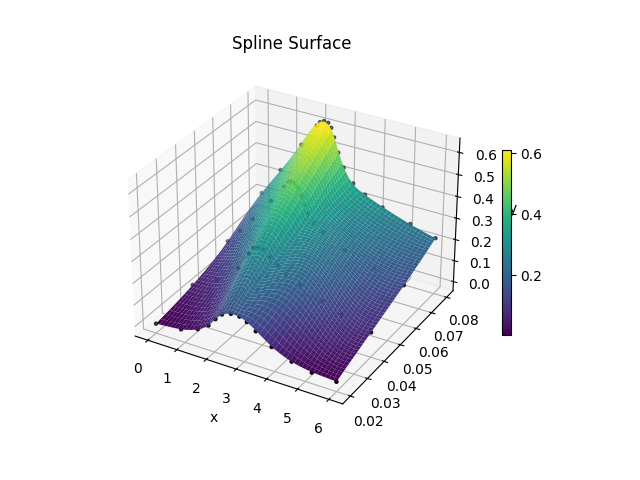

In [7]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

surfplot = ax.plot_surface(X1, X2, Y, cmap='viridis', linewidth=0, antialiased=True)
ax.scatter(data[:, 0],data[:, 1], data[:, 2], marker='.', color='black')
plt.colorbar(surfplot, ax=ax, shrink=0.5, label=surf.x2_label)

ax.set_xlabel(surf.x1_label)
ax.set_ylabel(surf.x2_label)
ax.set_zlabel(surf.y_label)
ax.set_title("Spline Surface")
plt.show()

## Evaluate surface for X-Y values using 'eval_point'

In [8]:
X1_, X2_ = np.meshgrid(x1_vals_ex, x2_vals_ex)
Y_ = np.zeros_like(X1_)

t1 = time()
for i in range(X1_.shape[0]):
    for j in range(X2_.shape[0]):
        Y_[i, j] = surf.eval_point(X1_[i, j], X2_[i, j], extrapolate=True)

t1 = time() - t1
t1

7.259005069732666

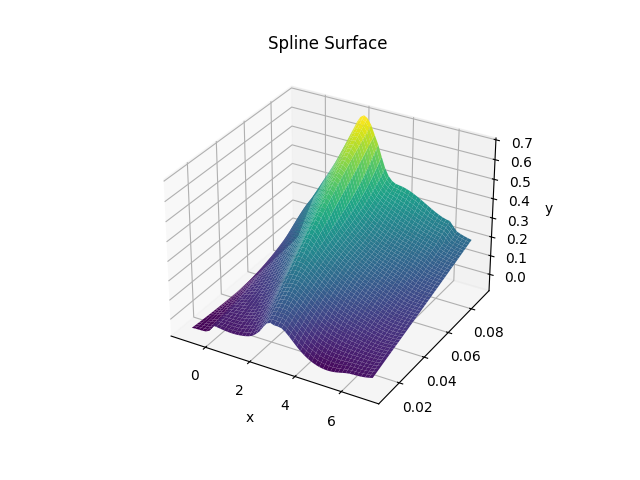

In [9]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

surfplot = ax.plot_surface(X1_, X2_, Y_, cmap='viridis', linewidth=0, antialiased=True)

ax.set_xlabel(surf.x1_label)
ax.set_ylabel(surf.x2_label)
ax.set_zlabel(surf.y_label)
ax.set_title("Spline Surface")
plt.show()

## Evaluate surface for X-Y values using 'eval_grid'

In [10]:
t2 = time()
X1_, X2_, Y_ = surf.eval_grid(x1_vals_ex, x2_vals_ex, extrapolate=True)
t2 = time() - t2
t2

7.705008029937744

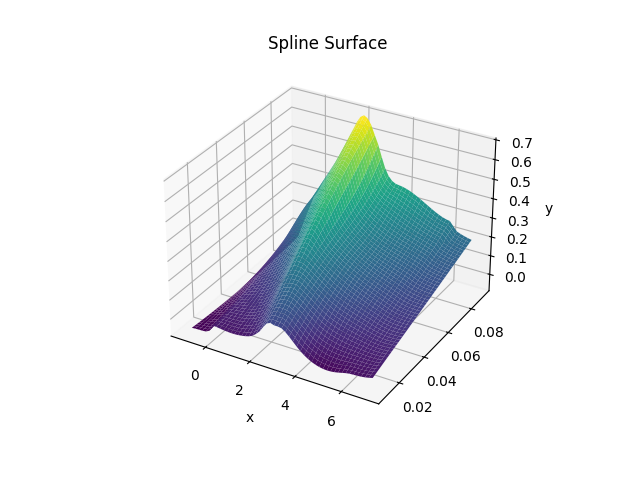

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

surfplot = ax.plot_surface(X1_, X2_, Y_, cmap='viridis', linewidth=0, antialiased=True)

ax.set_xlabel(surf.x1_label)
ax.set_ylabel(surf.x2_label)
ax.set_zlabel(surf.y_label)
ax.set_title("Spline Surface")
plt.show()

## Test gradient-based optimization

In [12]:
surf.eval(0.5, 4.5, compute_gradients=True, extrapolate=True)

(-249.72702234724844, (17.915698709753148, -93.1816836896035))

In [13]:
x1_avg = (x1_vals[0] + x1_vals[-1])/2
x2_avg = (x2_vals[0] + x2_vals[-1])/2
bounds = [[x1_vals[0], x1_vals[-1]], [x2_vals[0], x2_vals[-1]]]

In [14]:
def objective(x1x2):
    x1, x2 = x1x2
    y, grads = surf.eval(x1, x2, compute_gradients=True, extrapolate=True)
    return -y, np.array(grads)*(-1)

result = minimize(objective, x0=[x1_avg, x2_avg], bounds=bounds, jac=True, method='L-BFGS-B')
result

  message: ABNORMAL: 
  success: False
   status: 2
      fun: -0.6173911900672991
        x: [ 2.189e+00  8.000e-02]
      nit: 4
      jac: [ 6.290e-02 -7.248e+00]
     nfev: 48
     njev: 48
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

## Test gradient-free optimization

In [15]:
def objective(x1x2):
    x1, x2 = x1x2
    y = surf.eval(x1, x2, compute_gradients=False, extrapolate=True)
    return -y

result = minimize(objective, x0=[x1_avg, x2_avg], bounds=bounds)
result

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -0.6173984871544006
        x: [ 2.193e+00  8.000e-02]
      nit: 6
      jac: [-1.554e-07 -7.213e+00]
     nfev: 27
     njev: 9
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>